# Linear Algebra

While algorithms for matrix algebra are interesting, they are bit complicated to explore for the computational section of the Mathematical Physics I course.  Here we will rely more on python packages to solve linear algebra problems. One such package that we will introduce is the scipy package, which you will rely extensivley on this module. While matrix operations like matrix multiplication and dot products will be covered, the goal here will be to build up to the method of finite differences and build the intuition on what it means when we say "d/dx" is a linear operator and solve a quantum mechanics problem using your new found computational methods in linear algebra.

Topics:
1. Multidemsional Array and Matrix Operation Basics
2. expand on this section while more topics are added

For some information in the scipy package, it was built on top of the numpy package. It is far more opitmized than numpy for scientific computing. Numpy will handle all our basic functions such as creating arrays and basic operations and scipy will handle the actual matrix algebra.

In [3]:
#as always we import numpy and matplotlib :)
import numpy as np
import matplotlib.pyplot as plt 
from scipy import linalg   #scipy is made of a lot of different modules so we want import the exact ones we want.


## Getting Started with Multidimensional Array Basics
We will be using multidemnsional arrays to represent our matrices, so it's important to know how to work with them.
Let's construct the following matrix using a multidemnsional array:
\begin{bmatrix}
1 & 2 & 3\\
2 & 4 & 6\\
1 & 3 & 5
\end{bmatrix}

In [16]:
a = np.array([[1, 2, 3], 
              [2, 4, 6], 
              [1, 3, 5]])   ## I like to write my multidimensional arrays stacked like this to better visualize the outcome.
                            ## not needed to stack, but you should recoginize that it looks more like a matrix this way

In [17]:
a

array([[1, 2, 3],
       [2, 4, 6],
       [1, 3, 5]])

We can perform all the same operations on arrays as before, for example:

In [37]:
b = 2 * a  #every entry is multiplied by 2. Make your own coding cells and play around with it
b

array([[ 2,  4,  6],
       [ 4,  8, 12],
       [ 2,  6, 10]])

It's important to know how arrays are indexed. We can call for a specific rows like this:

In [38]:
b[2]  #again remember that counting starts from 0 so calling a[2] calls the third row of an array since 0 -> 1 -> 2

array([ 2,  6, 10])

For columns we use:

In [79]:
b[:,0]  #':' means to go across all rows but only take the 0th element (so the first column)

array([2, 4, 2])

In [80]:
b[1:,1]  # '1:'means go across the 2nd row and down. ',1' means you only want the 2nd element

array([8, 6])

In [87]:
b[1:,:2]  #'1:' means you only want the the 2nd row and down. ':2' means you only want to take 2 elements

array([[4, 8],
       [2, 6]])

## Matrix Operations
We will perform matrix operations on the following $$ A =
\begin{bmatrix}
1 & 2 & 3\\
2 & 4 & 6\\
1 & 3 & 5
\end{bmatrix} $$

Let's imagine the following the vectors: $\vec{b_1} = \begin{bmatrix} 2 \\ 2 \\ 2 \end{bmatrix}$, $\vec{b_2} = \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix} $, and $\vec{b_3} = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}$ 

Let's start defining the matrix again in a multidimensional array and our vectors which we will use one dimensional arrays :

In [94]:
#matrix A
A = np.array([[1, 2 ,3],
              [2, 4, 6],
              [1, 3, 5]])
#vectors b1, b2 ,b3
b1 = np.array([2, 2, 2])
b2 = np.array([1, 2, 3])
b3 = np.array([1, 0 , 0])

Multiply A by $\vec{b_1}$: $$ A\vec{b_1} =
\begin{bmatrix}
1 & 2 & 3\\
2 & 4 & 6\\
1 & 3 & 5
\end{bmatrix} \begin{bmatrix} 2 \\ 2 \\ 2 \end{bmatrix} = \begin{bmatrix} 12 \\ 24 \\ 18 \end{bmatrix}  $$

In [98]:
A@b1 

array([12, 24, 18])

To Transpose a matrix, $A^{T} $

In [92]:
A.T

array([[1, 2, 1],
       [2, 4, 3],
       [3, 6, 5]])

To take the dot product $\vec{b_1} \cdot \vec{b_2} $:

In [96]:
np.dot(b1, b2) #so newer version of python include the integer type of the value, you can write print() if this annoys you

np.int64(12)

To take a cross product $\vec{b_1} \times \vec{b_3}$:

In [97]:
np.cross(b1, b3)

array([ 0,  2, -2])

# Solving a System of Equations
We will be using np.linalg.solve(a,b) to solve a system of linear equations. This function computes the exact solution of a well determined nxn matrix. We will not be taking the inverse of a matrix to solve these types of problems because that is computational expensive. Suppose that we a system of equations in the form: $$x + 2y - z = 4 $$ $$2x  - z = 1 $$ $$x - 2y = -3 $$

Writen in the matrix equation form $A\vec{x}=\vec{b} $ we have:  $$
\begin{bmatrix}
1 & 2 & -1\\
2 & 0 & -1\\
2 & -2 & 0
\end{bmatrix} \begin{bmatrix} x \\ y \\ z \end{bmatrix} = \begin{bmatrix} 4 \\ 1 \\ -3 \end{bmatrix}  $$


In [23]:
#we want to solve for x. We should define A and B in terms of arrays
A = np.array([[1, 2, -1],
              [2, 0, -1],
              [2, -2, 0]])
b= np.array([4, 1, -3])
x = np.linalg.solve(A,b)
x

array([ 0. ,  1.5, -1. ])

In [31]:
# we can easily verify that x is a solution by multiplying the matrix by x
print("x = ", A@x  )

x =  [ 4.  1. -3.]


## Problem 1 - Parabolic Interpolation

Parabolic interpolation: Let's saw we need to fit a parabola in the form $f(x) = ax^2 + bx + c $ to three points $(x_1, f(x_1))$, $(x_2, f(x_2))$, $(x_3, f(x_3))$. We can rewrite this problem as a system of linear equations with three unknowns a, b, and c: 
$$ ax_1^2 + bx_1 + c = f(x_1) $$
$$ ax_2^2 + bx_2 + c = f(x_2) $$
$$ ax_3^2 + bx_3 + c = f(x_3) $$ which in matrix form is :

$$
\begin{bmatrix}
x_1^2 & x_1 & 1\\
x_2^2 & x_2 & 1\\
x_3^2 & x_3 & 1
\end{bmatrix} \begin{bmatrix} a \\ b \\ c \end{bmatrix} = \begin{bmatrix} f(x_1) \\ f(x_2) \\ f(x_3) \end{bmatrix}  $$
Let's say we have three specific points of data: (0.5, 2), (1, 1) and (4,8). The matrix then becomes:
$$
\begin{bmatrix}
0.25 & 0.5 & 1\\
1 & 1 & 1\\
16 & 4 & 1
\end{bmatrix} \begin{bmatrix} a \\ b \\ c \end{bmatrix} = \begin{bmatrix} 2 \\ 1 \\ 8 \end{bmatrix}  $$
Solve the matrix, plot the function you get from solving, and plot the points.


In [44]:
A = np.array([[0.25, 0.5, 1],
          [1,      1, 1],
          [16,     4, 1]])

b = np.array([2, 1 ,8])
x = np.linalg.solve(A, b)
print(x)
print("a = ", x[0], "b = ", x[1], "c = ", x[2])

[ 1.23809524 -3.85714286  3.61904762]
a =  1.2380952380952381 b =  -3.857142857142857 c =  3.619047619047619


So know we have oour coefficients. We can say $f(x) \approx 1.238095x^2 - 3.857143x + 3.619048$

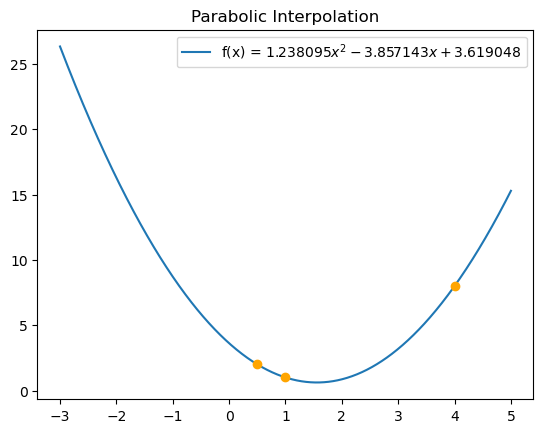

In [71]:
x = np.linspace(-3, 5, 1000)
y = 1.238096 * x **2 - 3.857143 * x + 3.619048
plt.plot(x,y, label="f(x) = $1.238095x^2 - 3.857143x + 3.619048$")
plt.title('Parabolic Interpolation')
plt.legend()
plt.plot(0.5, 2, 'o', color = 'orange')  
plt.plot(1, 1, 'o', color = 'orange')
plt.plot(4, 8, 'o', color = 'orange')

# Visualizing Matrix Transformations
It is my belief that any good course in linear algebra will show you graphically what you are doing when you apply a transformation. Mathematical Physics 1 is not a course in linear algebra, so it's difficult to spend a lot of time understanding the mathematics. Here are some tools that will better allow you to understand what it means to apply a transformation.

A matrix can transform vectors. Let's imagine the following matrix: $$ A =
\begin{bmatrix}
2 & 0 \\
1 & 4 
\end{bmatrix} $$ and vector: $$\vec{v} = \begin{bmatrix} 1 \\ 1 \end{bmatrix} $$ Let's see how v compares to Av:

In [76]:
A = np.array([[2, 0], 
             [1, 4]])
v = np.array([1, 1])

Av = A@v #here is our transformation
print("v =", v)
print("A v =", Av)

v = [1 1]
A v = [2 5]


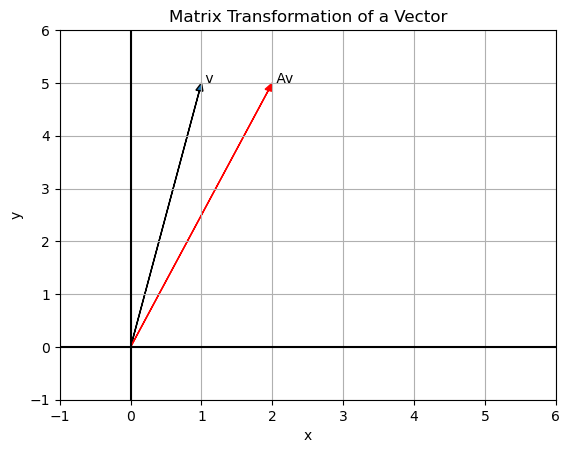

In [109]:
#plotting vectors

#plt.arrow(x, y, change in x, change in y)
plt.arrow(0, 0, v[0], v[1], head_width=0.1, length_includes_head=True)
plt.text(v[0], v[1], " v")

plt.arrow(0, 0, Av[0], Av[1], color = 'red', head_width=0.1, length_includes_head=True)
plt.text(Av[0], Av[1], " Av")

#this makes axis more visible
plt.axhline(0, color="black",)
plt.axvline(0, color="black",)

plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Matrix Transformation of a Vector")
plt.grid()
plt.show()

The rotation matrix: $$ R = \begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix} $$
Let's see what happens when $\theta = \pi/4 $ using $\vec{v} = \begin{bmatrix} 3 \\ 0 \end{bmatrix} $

In [133]:
theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])
v = np.array([3, 0])

Rv = R@v

print("v = ", v)
print("Rotated v = ", Rv)

v =  [3 0]
Rotated v =  [2.12132034 2.12132034]


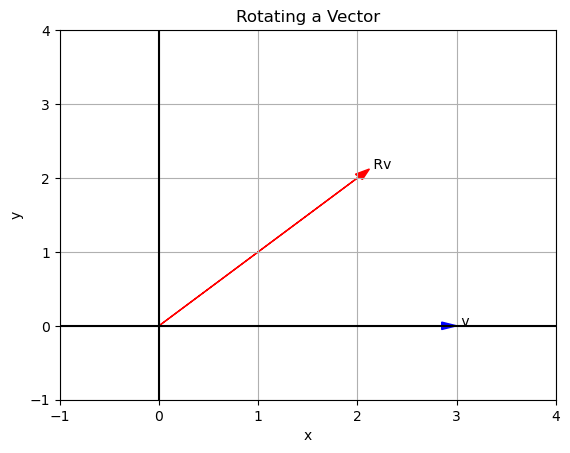

In [134]:
#plt.arrow(x, y, change in x, change in y)
plt.arrow(0, 0, v[0], v[1], color = 'blue', head_width=0.1, length_includes_head=True)
plt.text(v[0], v[1], " v")

plt.arrow(0, 0, Rv[0], Rv[1], color = 'red', head_width=0.1, length_includes_head=True)
plt.text(Rv[0], Rv[1], " Rv")   #there is a funciton called quiver() for vectors. It was giving me issues with scalin

#this makes axis more visible
plt.axhline(0, color="black",)
plt.axvline(0, color="black",)

plt.xlim(-1, 4)
plt.ylim(-1, 4)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Rotating a Vector")
plt.grid()
plt.show()

We can see that the vector was rotated counterclockwise

## Problem: Rotate the same vector $\vec{v}$ by $\pi/2 $
$$ R = \begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix} $$ 
$$\vec{v} = \begin{bmatrix} 3 \\ 0 \end{bmatrix} $$

In [135]:
theta = np.pi / 2  #change this
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])
v = np.array([3, 0])

Rv = R@v

print("v = ", v)
print("Rotated v = ", Rv)

v =  [3 0]
Rotated v =  [1.8369702e-16 3.0000000e+00]


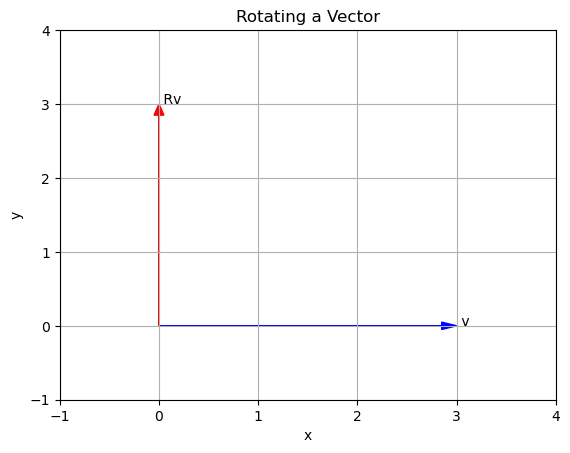

In [136]:
plt.arrow(0, 0, v[0], v[1], color = 'blue', head_width=0.1, length_includes_head=True)
plt.text(v[0], v[1], " v")

plt.arrow(0, 0, Rv[0], Rv[1], color = 'red', head_width=0.1, length_includes_head=True)
plt.text(Rv[0], Rv[1], " Rv")

plt.xlim(-1, 4)
plt.ylim(-1, 4)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Rotating a Vector")
plt.grid()
plt.show()

# Eigenvalues and Eigenvectors

An eigenvector is a vector whose direction is unchanged or reversed when a linear transformation is applied and is scaled by some factor $\lambda$. $$A\vec{v} = \lambda\vec{v} $$ Where $\vec{v}$ is the eigen vector and $\lambda$ is the eigenvalue.

In [139]:
A = np.array([[2, 1],
              [1, 2]])

eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:")
print(eigenvalues)

print("Eigenvectors:")
print(eigenvectors)

Eigenvalues:
[3. 1.]
Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
